# UCI Heart Disease Prediction — Fresh Notebook

This notebook is built from scratch for the **UCI Heart Disease dataset**.

## Goals
- build a clean machine learning workflow
- study supervised learning step by step
- compare **Logistic Regression** and **Random Forest**
- evaluate the models properly
- interpret the results for class, GitHub, and your CV

## Problem Type
This is a **binary classification** problem.

We will use:
- `num = 0` → no heart disease
- `num > 0` → heart disease present

## Step 1 — Import libraries

In [35]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## Step 2 — Load the dataset

Put your UCI CSV file inside the `data/` folder and rename it to:

`heart_uci.csv`

In [36]:
DATA_PATH = Path("data/heart_uci.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 3 — Explore the data

In [37]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

Shape: (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), obje

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

## Step 4 — Clean the dataset and define the target

In the UCI dataset:
- `num = 0` means **no disease**
- `num = 1,2,3,4` means **disease present**

In [38]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

TARGET_COL = "num"

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].apply(lambda x: 0 if x == 0 else 1).astype(int)

print("Target distribution:")
display(df[TARGET_COL].value_counts(dropna=False))

print("\nTarget proportions:")
display(df[TARGET_COL].value_counts(normalize=True))

Target distribution:


num
1    509
0    411
Name: count, dtype: int64


Target proportions:


num
1    0.553261
0    0.446739
Name: proportion, dtype: float64

## Step 5 — Separate features and target

In [39]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique target values:", sorted(y.unique().tolist()))

X shape: (920, 14)
y shape: (920,)
Unique target values: [0, 1]


## Step 6 — Identify numeric and categorical columns

In [40]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## Step 7 — Build preprocessing pipelines

In [41]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Step 8 — Split into training and test sets

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (736, 14)
Test set: (184, 14)

Training target distribution:
num
1    0.552989
0    0.447011
Name: proportion, dtype: float64

Test target distribution:
num
1    0.554348
0    0.445652
Name: proportion, dtype: float64


## Step 9 — Train Logistic Regression

In [43]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)
logistic_preds = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_preds)
print("Logistic Regression accuracy:", round(logistic_accuracy, 4))

Logistic Regression accuracy: 0.8424


c:\Users\AMAZONCA1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 9.1 — Evaluate Logistic Regression

In [44]:
print("Confusion Matrix (Logistic):")
print(confusion_matrix(y_test, logistic_preds))

print("\nClassification Report (Logistic):")
print(classification_report(y_test, logistic_preds, zero_division=0))

Confusion Matrix (Logistic):
[[63 19]
 [10 92]]

Classification Report (Logistic):
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        82
           1       0.83      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



## Step 10 — Train Random Forest

In [45]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest accuracy:", round(rf_accuracy, 4))

Random Forest accuracy: 0.8533


## Step 10.1 — Evaluate Random Forest

In [46]:
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_preds))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_preds, zero_division=0))

Confusion Matrix (Random Forest):
[[67 15]
 [12 90]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## Step 11 — Compare the models

In [47]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy]
}).sort_values("Accuracy", ascending=False)

comparison_df

,Model,Accuracy
1,Random Forest,0.853261
0,Logistic Regression,0.842391


## Step 12 — Feature importance from Random Forest

In [48]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
12,cat__cp_asymptomatic,0.106387
2,num__chol,0.094829
3,num__thalch,0.094738
0,num__age,0.088804
4,num__oldpeak,0.086482
22,cat__exang_True,0.064714
1,num__trestbps,0.056761
21,cat__exang_False,0.054816
13,cat__cp_atypical angina,0.042143
10,cat__dataset_Switzerland,0.032361


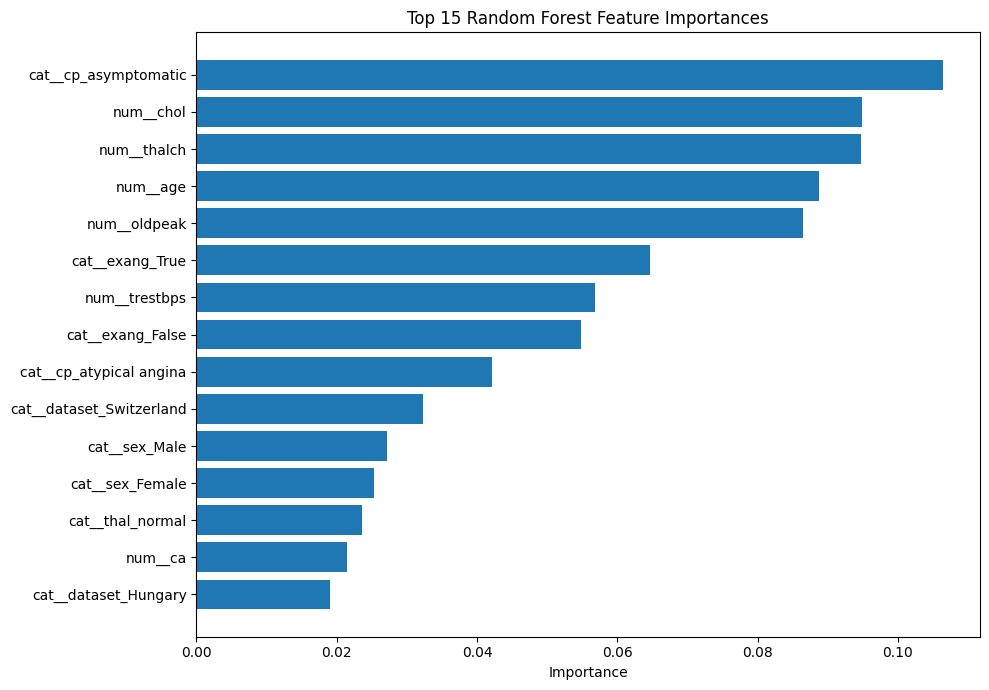

In [49]:
top = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Step 13 — Save outputs

In [52]:
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

best_model = rf_pipeline if rf_accuracy >= logistic_accuracy else logistic_pipeline
best_model_name = "Random Forest" if rf_accuracy >= logistic_accuracy else "Logistic Regression"

joblib.dump(best_model, OUTPUT_DIR / "best_model.joblib")

metrics = {
    "logistic_regression_accuracy": float(logistic_accuracy),
    "random_forest_accuracy": float(rf_accuracy),
    "best_model": best_model_name
}

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs successfully.")
print("Best model:", best_model_name)

Saved outputs successfully.
Best model: Random Forest


## Step 14 — My Final conclusion prompts


1. Random Forest model performed slightly better than Logistic Regression model, by achieving an accuracy of 85.33% compared to 84.24%. Additionally, Random Forest provided a more balanced performance across both classes, making it the better overall model for this dataset.

2. Also observed that both models were able to detect disease cases, as they recorded positive heart disease cases. Logistic Regression achieved a recall of 0.90 for the positive class, correctly identifying most patients with heart disease. Random Forest also performed well, with a recall of 0.88, confirming that both models were effective in identifying disease cases.

3. The most important features identified by the Random Forest model included chest pain type (particularly asymptomatic chest pain), cholesterol levels, maximum heart rate, age, oldpeak (ST depression), and exercise-induced angina. These features are clinically relevant and strongly associated with heart disease risk.

4. Accuracy alone for this project was not sufficient because it does not account for class imbalance or the cost of misclassification.In medical applications, failing to detect a positive case (false negative) can have serious consequences. Therefore, metrics such as recall, precision, and the confusion matrix provide a more complete evaluation of model performance.

5. Future improvements could include hyperparameter tuning to optimize model performance, experimenting with additional algorithms such as Gradient Boosting, and performing feature engineering to enhance predictive power. Additionally, using cross-validation and evaluating metrics such as ROC-AUC would provide a more robust assessment of model generalization.